## Feature Engineering - Day 

In [ ]:
#importing required libraries
import pandas as pd
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler

In [2]:
# Load data
df_day = pd.read_csv('day.csv')
print(f"Original dataset shape: {df_day.shape}")
df_day.head()

Original dataset shape: (731, 16)


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


## Data Cleaning & Preprocessing

In [3]:
# Convert date column
df_day['dteday'] = pd.to_datetime(df_day['dteday'])
df_day['day'] = df_day['dteday'].dt.day

# Drop unnecessary columns
df_day.drop(['instant', 'dteday'], axis=1, inplace=True)

print("After initial cleaning:", df_day.shape)

After initial cleaning: (731, 15)


##Remove Target Leakage Features

In [ ]:
#Remove columns that leak information about the target
# casual + registered = cnt (the target), so these must be removed
leakage_cols = ['casual', 'registered']
df_day.drop(leakage_cols, axis=1, inplace=True)
print("Removed leakage columns:", leakage_cols)

Removed leakage columns: ['casual', 'registered']


## Feature Engineering

In [ ]:

# weekend indicator
df_day['is_weekend'] = df_day['weekday'].apply(lambda x: 1 if x in [0, 6] else 0)

# Cyclic encoding for temporal features
df_day['mnth_sin'] = np.sin(2 * np.pi * df_day['mnth'] / 12)
df_day['mnth_cos'] = np.cos(2 * np.pi * df_day['mnth'] / 12)
df_day['weekday_sin'] = np.sin(2 * np.pi * df_day['weekday'] / 7)
df_day['weekday_cos'] = np.cos(2 * np.pi * df_day['weekday'] / 7)
df_day['day_sin'] = np.sin(2 * np.pi * df_day['day'] / 31)
df_day['day_cos'] = np.cos(2 * np.pi * df_day['day'] / 31)

# Drop original temporal columns
df_day.drop(['mnth', 'weekday', 'day'], axis=1, inplace=True)

#  One-hot encode categorical features
categorical_cols = ['season', 'weathersit']
df_day = pd.get_dummies(df_day, columns=categorical_cols, drop_first=True, dtype=int)

# Interaction features
df_day['temp_humidity'] = df_day['temp'] * df_day['hum']
df_day['temp_windspeed'] = df_day['temp'] * df_day['windspeed']
df_day['humidity_windspeed'] = df_day['hum'] * df_day['windspeed']
df_day['temp_squared'] = df_day['temp'] ** 2
df_day['holiday_workday'] = df_day['holiday'] * df_day['workingday']

#  Composite features
df_day['temp_comfort'] = df_day['temp'] * (1 - df_day['hum'])
df_day['weather_temp_interaction'] = df_day['temp'] * df_day['hum']  # Another angle

print(f"After all feature engineering: {df_day.shape}")
print(f"Features created: {df_day.shape[1] - 1}")  # -1 for target

After all feature engineering: (731, 27)
Features created: 26


##  Check for Multicollinearity

In [6]:
correlation_matrix = df_day.corr()

# Find highly correlated feature pairs (excluding target)
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        col_i = correlation_matrix.columns[i]
        col_j = correlation_matrix.columns[j]
        corr_val = correlation_matrix.iloc[i, j]

        if abs(corr_val) > 0.85 and col_i != 'cnt' and col_j != 'cnt':
            high_corr_pairs.append((col_i, col_j, corr_val))

if high_corr_pairs:
    print("⚠️  Highly correlated feature pairs (|corr| > 0.85):")
    for col1, col2, corr in high_corr_pairs:
        print(f"  {col1} <-> {col2}: {corr:.3f}")
else:
    print("✓ No highly correlated feature pairs found")

# Visualize correlation with target
target_corr = correlation_matrix['cnt'].drop('cnt').sort_values(ascending=False)
print("\nTop 10 features by correlation with target:")
print(target_corr.head(10))

⚠️  Highly correlated feature pairs (|corr| > 0.85):
  workingday <-> is_weekend: -0.934
  temp <-> atemp: 0.992
  temp <-> temp_humidity: 0.862
  temp <-> temp_squared: 0.985
  temp <-> weather_temp_interaction: 0.862
  atemp <-> temp_humidity: 0.860
  atemp <-> temp_squared: 0.972
  atemp <-> weather_temp_interaction: 0.860
  temp_humidity <-> weather_temp_interaction: 1.000

Top 10 features by correlation with target:
atemp                       0.631066
temp                        0.627494
temp_squared                0.576172
yr                          0.566710
temp_comfort                0.559956
temp_humidity               0.450343
weather_temp_interaction    0.450343
season_3                    0.346487
temp_windspeed              0.286312
season_2                    0.146197
Name: cnt, dtype: float64


## Prepare Features and Target

In [7]:
# separate features and target
X = df_day.drop('cnt', axis=1).copy()
y = df_day['cnt'].copy()

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (731, 26)
Target shape: (731,)


## Feature Selection with Cross-Validation

In [8]:
#  Use K-Fold cross-validation for more robust feature importance
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

feature_importance_cv = pd.DataFrame({
    'Feature': X.columns,
    'Importance_Mean': 0.0,
    'Importance_Std': 0.0
})

all_importances = {col: [] for col in X.columns}

# Train RF on each fold and collect importance scores
fold = 1
for train_idx, test_idx in kfold.split(X):
    X_train_fold = X.iloc[train_idx]
    X_test_fold = X.iloc[test_idx]
    y_train_fold = y.iloc[train_idx]
    y_test_fold = y.iloc[test_idx]

    # Train model
    rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1, max_depth=15)
    rf.fit(X_train_fold, y_train_fold)

    # Get permutation importance
    perm = permutation_importance(rf, X_test_fold, y_test_fold, n_repeats=10, random_state=42)

    for feature, imp in zip(X.columns, perm.importances_mean):
        all_importances[feature].append(imp)

    print(f"Fold {fold} completed")
    fold += 1

# Calculate mean and std across folds
for feature in X.columns:
    feature_importance_cv.loc[feature_importance_cv['Feature'] == feature, 'Importance_Mean'] = np.mean(all_importances[feature])
    feature_importance_cv.loc[feature_importance_cv['Feature'] == feature, 'Importance_Std'] = np.std(all_importances[feature])

# Sort by mean importance
feature_importance_cv = feature_importance_cv.sort_values('Importance_Mean', ascending=False).reset_index(drop=True)

print("\nCross-Validation Feature Importance (Top 20):")
print(feature_importance_cv.head(20))

Fold 1 completed
Fold 2 completed
Fold 3 completed
Fold 4 completed
Fold 5 completed

Cross-Validation Feature Importance (Top 20):
                     Feature  Importance_Mean  Importance_Std
0                         yr         0.529112        0.021774
1                      atemp         0.093493        0.027183
2               temp_squared         0.092559        0.009218
3                       temp         0.064837        0.004450
4                   season_4         0.060433        0.006364
5               temp_comfort         0.041938        0.011401
6                   mnth_sin         0.026633        0.008589
7                        hum         0.018146        0.006773
8         humidity_windspeed         0.012256        0.005740
9                    day_sin         0.009159        0.003226
10               weekday_sin         0.005345        0.002422
11                 windspeed         0.003311        0.001835
12               weekday_cos         0.002672        0.001691


## Select Features Based on Domain Knowledge + Importance

In [9]:

# Only kept features with importance > 0.002
# AND keep known important domain features

importance_threshold = 0.002
domain_features = ['temp', 'hum', 'windspeed', 'workingday', 'holiday', 'is_weekend']

# Get features by importance
important_features = feature_importance_cv[feature_importance_cv['Importance_Mean'] > importance_threshold]['Feature'].tolist()

# Add domain features if not already included
selected_features = list(set(important_features + [f for f in domain_features if f in X.columns]))
selected_features.sort()

print(f"Selected {len(selected_features)} features using threshold {importance_threshold}:")
print(sorted(selected_features))

# Show which features were NOT selected
removed_features = [f for f in X.columns if f not in selected_features]
print(f"\nRemoved {len(removed_features)} features (likely noise):")
for f in removed_features:
    imp = feature_importance_cv[feature_importance_cv['Feature'] == f]['Importance_Mean'].values[0]
    print(f"  {f}: {imp:.6f}")

Selected 19 features using threshold 0.002:
['atemp', 'day_sin', 'holiday', 'hum', 'humidity_windspeed', 'is_weekend', 'mnth_cos', 'mnth_sin', 'season_4', 'temp', 'temp_comfort', 'temp_humidity', 'temp_squared', 'weather_temp_interaction', 'weekday_cos', 'weekday_sin', 'windspeed', 'workingday', 'yr']

Removed 7 features (likely noise):
  day_cos: 0.000286
  season_2: 0.001655
  season_3: -0.000021
  weathersit_2: 0.001011
  weathersit_3: 0.001823
  temp_windspeed: 0.000719
  holiday_workday: 0.000000


## Create Final Dataset

In [10]:
# Create final dataset with selected features
df_final = df_day[selected_features + ['cnt']].copy()

# Save to CSV
df_final.to_csv('day_dataset_featured_new.csv', index=False)

print(f"✓ Saved improved dataset to: day_dataset_featured_improved.csv")
print(f"Final dataset shape: {df_final.shape}")
print(f"Selected features: {len(selected_features)}")

✓ Saved improved dataset to: day_dataset_featured_improved.csv
Final dataset shape: (731, 20)
Selected features: 19


##Visualize Feature Selection Results

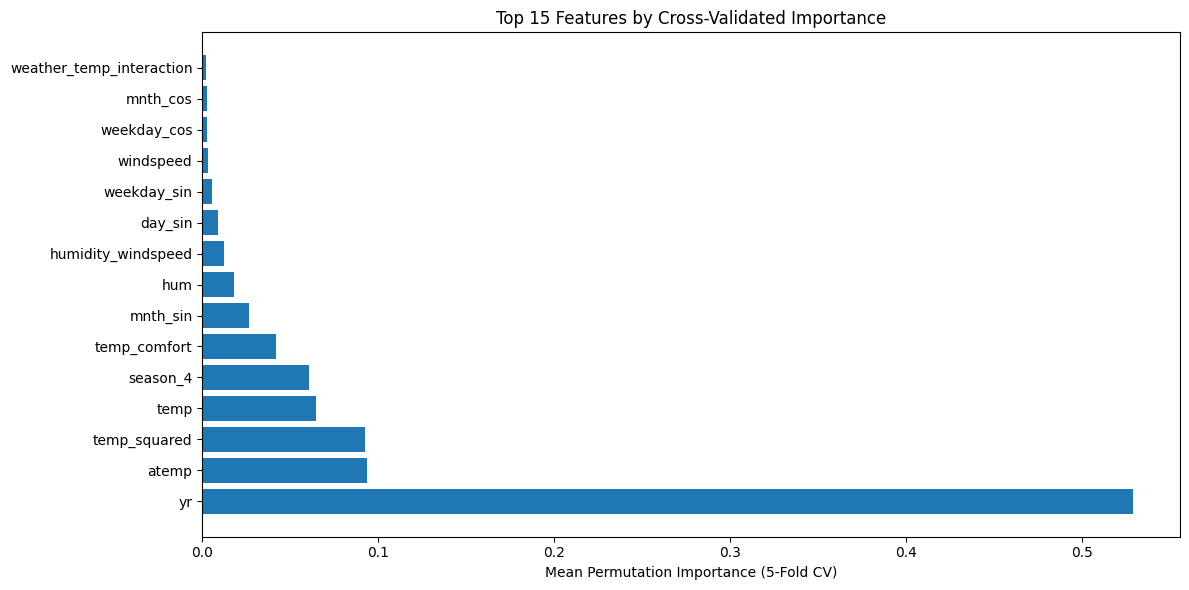

✓ Feature selection visualization complete


In [11]:
# Plot top 15 features by importance
plt.figure(figsize=(12, 6))
top_features = feature_importance_cv.head(15)
plt.barh(range(len(top_features)), top_features['Importance_Mean'])
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Mean Permutation Importance (5-Fold CV)')
plt.title('Top 15 Features by Cross-Validated Importance')
plt.tight_layout()
plt.show()

print("✓ Feature selection visualization complete")